In [28]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Image

## Word2Vec(word to vector)
- 의미가 비슷한 단어는 벡터 공간에서 서로 가까운 위치에 존재하도록 변환하는 알고리즘  
- 비지도학습으로 말뭉치 데이터만 있으면 쉽게 word2vec를 구할 수 있다(label이 자동으로 생성되느 장점)

In [29]:
# 말뭉치 : corpus
corpus = ['king is a strong man', 
          'queen is a wise woman', 
          'boy is a young man',
          'girl is a young woman',
          'prince is a young king',
          'princess is a young queen',
          'man is strong', 
          'woman is pretty',
          'prince is a boy will be king',
          'princess is a girl will be queen']

### 전처리 - stop words 제거하기
- stop words란 학습에 도움이 되지도 않으면서 빈번하게 발생되는 단어를 의미

In [30]:
def remove_stop_words(corpus):
    stop_words = ['is', 'a', 'will', 'be']
    results = []

    for text in corpus:
        tmp = text.split(' ')
        print(tmp)
        for stop_word in stop_words:
            if stop_word in tmp:
                tmp.remove(stop_word)
        results.append(" ".join(tmp))     
        
    return results        

In [31]:
corpus = remove_stop_words(corpus)

['king', 'is', 'a', 'strong', 'man']
['queen', 'is', 'a', 'wise', 'woman']
['boy', 'is', 'a', 'young', 'man']
['girl', 'is', 'a', 'young', 'woman']
['prince', 'is', 'a', 'young', 'king']
['princess', 'is', 'a', 'young', 'queen']
['man', 'is', 'strong']
['woman', 'is', 'pretty']
['prince', 'is', 'a', 'boy', 'will', 'be', 'king']
['princess', 'is', 'a', 'girl', 'will', 'be', 'queen']


In [32]:
for text in corpus:
    print(text)

king strong man
queen wise woman
boy young man
girl young woman
prince young king
princess young queen
man strong
woman pretty
prince boy king
princess girl queen


In [33]:
words = []

for text in corpus:
    for word in text.split(' '):
        words.append(word)
        
words = set(words)

In [34]:
words

{'boy',
 'girl',
 'king',
 'man',
 'pretty',
 'prince',
 'princess',
 'queen',
 'strong',
 'wise',
 'woman',
 'young'}

### 단어별 인덱스 매핑 테이블 만들기

In [35]:
word2int = {}

for i, word in enumerate(words):
    word2int[word] = i

In [36]:
word2int

{'boy': 0,
 'princess': 1,
 'king': 2,
 'pretty': 3,
 'young': 4,
 'girl': 5,
 'wise': 6,
 'prince': 7,
 'woman': 8,
 'queen': 9,
 'strong': 10,
 'man': 11}

### label 생성
- skip gram 방식으로 각 단어별 레이블을 생성하도록 하겠음, 중심 단어를 중심으로 주변 단어를 예측해 본다

In [37]:
sentences = []

# stop_words = ['is', 'a', 'will', 'be']
for sentence in corpus:
    sentences.append(sentence.split()) # 단어의 스페이스를 기준으로 해당 단어들을 개별적으로 split(쪼갠다)
    
WINDOW_SIZE = 2  # I like eating red appls today, eating을 중심으로 한 두개의 단어(eating I, eating like, eating red, eating appls)

# WINDOW_SIZE를 기준으로 중심 단어와 주변 단어를 어떻게 가져갈 것인가?
# 의미가 비슷한 단어들이 같은 공간에 위치하게 된다(word2vec)

data = []
for sentence in sentences:
    for idx, word in enumerate(sentence):  # 인덱스 0 중심
        # 중심 단어를 앞뒤로 두개 단어순, max값은 0을 넘지 않도록, min값은 0보다 작지 않도록
        for neighbor in sentence[ \
            max(idx - WINDOW_SIZE, 0) :  \
            min(idx + WINDOW_SIZE, len(sentence)) + 1 ]:
            if neighbor != word: # 내 자신을 제외하고 나머지 추가
                data.append([word, neighbor])

In [38]:
df = pd.DataFrame(data, columns=['input', 'label'])
df.head(10)

,input,label
0,king,strong
1,king,man
2,strong,king
3,strong,man
4,man,king
5,man,strong
6,queen,wise
7,queen,woman
8,wise,queen
9,wise,woman


## 텐서플로우로 word2vec 모델 구현하기

In [39]:
ONE_HOT_DIM = len(words)

def to_one_hot_encoding(data_point_index):
    one_hot_encoding = np.zeros(ONE_HOT_DIM)
    one_hot_encoding[data_point_index] = 1
    return one_hot_encoding

In [40]:
X = []
Y = []

for x, y in zip(df['input'], df['label']):
    X.append(to_one_hot_encoding(word2int[x]))
    Y.append(to_one_hot_encoding(word2int[y]))
    
X_train = np.asarray(X)
Y_train = np.asarray(Y)

In [41]:
encoding_dim = 2

input_word = Input(shape=(ONE_HOT_DIM,))
encoded = Dense(encoding_dim, use_bias=False)(input_word)  # 입력 레이어
decoded = Dense(ONE_HOT_DIM, activation='softmax')(encoded) # 출력 레이어

w2v_model = Model(input_word, decoded)

In [42]:
# 학습
w2v_model.compile(loss='categorical_crossentropy', optimizer='adam')

In [43]:
w2v_model.fit(X_train, Y_train, epochs=1000, shuffle=True, verbose=1)

Epoch 1/1000


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.4974 
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.4959
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 2.4944  
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.4931
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.4918
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.4905
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 2.4892  
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step - loss: 2.4879
Epoch 9/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.4866
Epoch 10/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.4855
Epoch 11/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.4841
Epoch 12/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.4830
Epoch 13/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4818 
Epoch 14/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.4805
Epoch 15/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.4793
Epoch 16/1000
2

In [44]:
# word2vec 추출하기, 학습된 최적의 가중치 w값을 출력
vectors = w2v_model.layers[1].weights[0].numpy().tolist()

### word2vec의 좌표값
- 2d 차트에서의 각 단어의 좌표값을 볼 수 있음

In [45]:
w2v_df = pd.DataFrame(vectors, columns=['x1', 'x2'])
w2v_df['word'] = list(words) # word 컬럼 추가
w2v_df = w2v_df[['word', 'x1', 'x2']] # 컬럼 순서 재배치
w2v_df

,word,x1,x2
0,boy,1.359496,1.143064
1,princess,-1.373091,0.601945
2,king,1.874548,0.145203
3,pretty,-0.856823,-1.821288
4,young,0.102154,-0.032581
5,girl,0.042830,-0.783301
6,wise,-1.551115,-0.952208
7,prince,0.783991,1.616797
8,woman,-1.081642,0.394434
9,queen,0.435039,-0.918715


### word2vec를 2차원 공간에 시각화하기

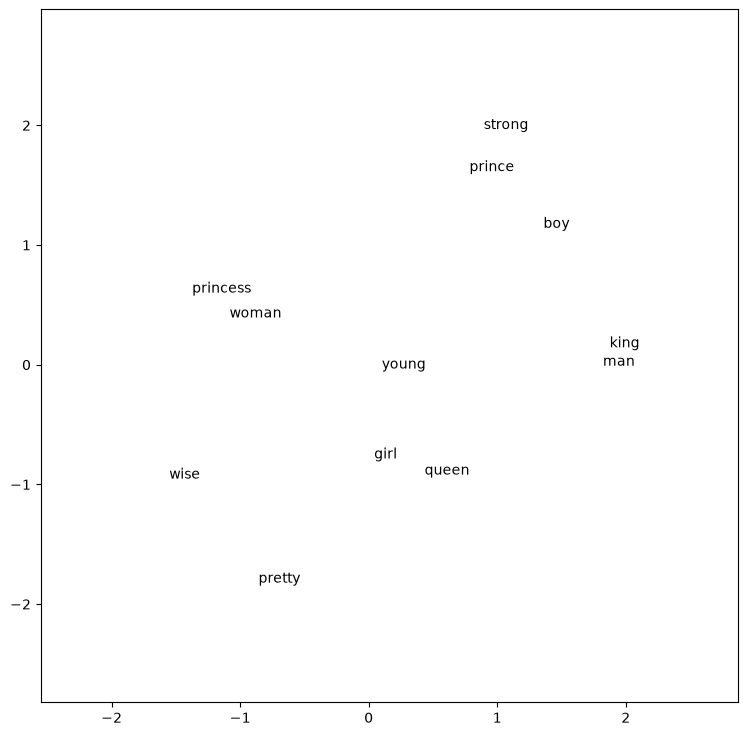

In [46]:
fig, ax = plt.subplots()

for word, x1, x2 in zip(w2v_df['word'], w2v_df['x1'], w2v_df['x2']):
    ax.annotate(word, (x1, x2))

PADDING = 1.0
x_axis_min = np.amin(vectors, axis=0)[0] - PADDING
y_axis_min = np.amin(vectors, axis=0)[1] - PADDING
x_axis_max = np.amax(vectors, axis=0)[0] + PADDING
y_axis_max = np.amax(vectors, axis=0)[1] + PADDING

plt.xlim(x_axis_min, x_axis_max)
plt.ylim(y_axis_min, y_axis_max)
plt.rcParams['figure.figsize'] = [9, 9]